In [58]:
import matplotlib.pyplot as plt
import torch
import numpy as np

In [6]:
with open("../data/names.txt", 'r') as f:
    words = f.read().splitlines()

In [14]:
b = {}
for w in words[:3]:
    chs = '.' + w + '.'
    for ch1 ,ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


In [16]:
b.items()

dict_items([(('.', 'e'), 1), (('e', 'm'), 1), (('m', 'm'), 1), (('m', 'a'), 1), (('a', '.'), 3), (('.', 'o'), 1), (('o', 'l'), 1), (('l', 'i'), 1), (('i', 'v'), 1), (('v', 'i'), 1), (('i', 'a'), 1), (('.', 'a'), 1), (('a', 'v'), 1), (('v', 'a'), 1)])

In [82]:
start = ord('a'); end = start + 26
chars = [chr(i) for i in range(start, end)]

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [47]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [65]:
for w in words:
    chs = '.' + w + '.'
    for ch1 ,ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        i, j = stoi[ch1], stoi[ch2]
        N[i, j] +=1

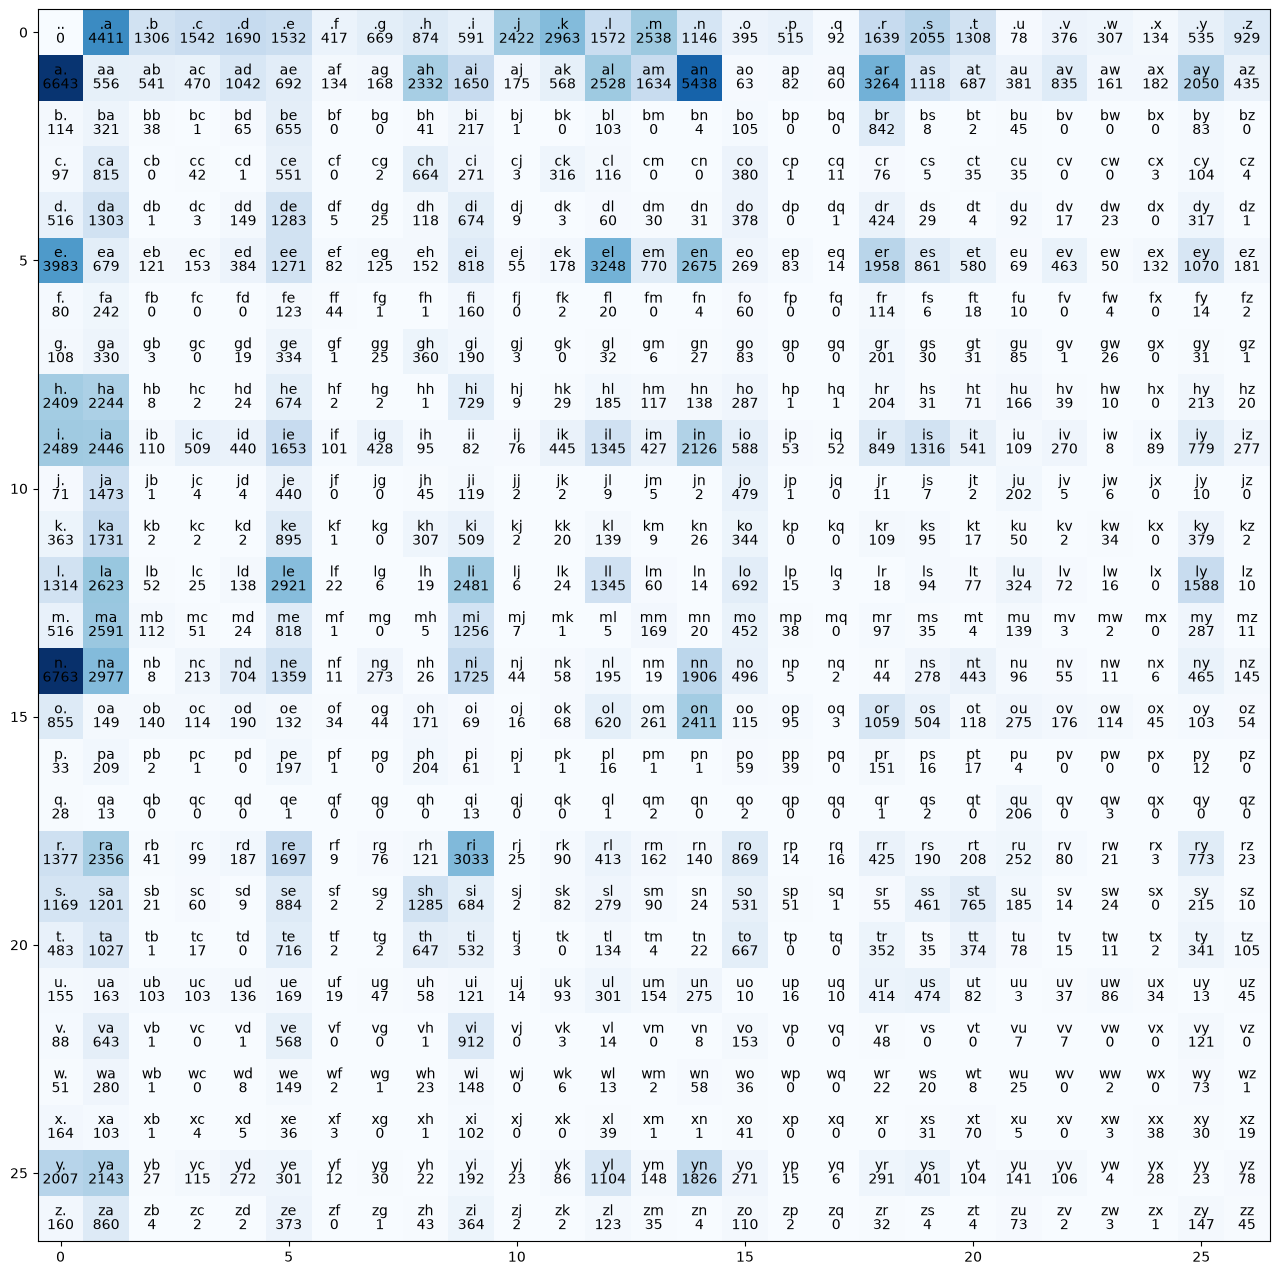

In [85]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom")
        plt.text(j, i, N[i, j].item(), ha="center", va="top")

plt.show()



In [73]:
N


tensor([[   0, 4411, 1306, 1542, 1690, 1532,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  395,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6643,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  835,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

In [95]:
g = torch.Generator().manual_seed(101)

ix = 0
while True:
    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    print(itos[ix])
    
    if ix == 0:
        break

j
e
.
